# Loss balancing and the NTK condition number (Numerical Example #7)

In this notebook we illustrate the analysis of **soft-constraint balancing** through the
lens of the Neural Tangent Kernel (NTK).

The example is intentionally linear: we replace the empirical NTK of a real PINN by two
synthetic blocks with prescribed spectra. This lets us isolate the effect of the loss
weights $\gamma$ and of spatially adaptive weighting on the condition number
$\kappa(\Theta^{(\gamma)})$ and on the convergence of gradient descent.

We compare three strategies:
1. **Uniform weights** $\gamma_\Omega = \gamma_\Gamma = 1$;
2. **GradNorm-style inter-block balancing**, which drives $\gamma_\Omega\lambda_{\max}^{(\Omega)} \approx \gamma_\Gamma\lambda_{\max}^{(\Gamma)}$;
3. **GradNorm combined with spatially adaptive (intra-block) weighting**, which additionally compresses the residual-block spectrum.

For each strategy we (i) compute the composite spectrum and condition number, (ii) simulate gradient descent on a quadratic
with that spectrum, and (iii) compare the empirical convergence to the predicted contraction factor $\rho = \frac{\kappa(\Theta^{(\gamma)})-1}{\kappa(\Theta^{(\gamma)})+1}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 1. Setup: synthetic block spectra

We assume the empirical NTK has a block-diagonal structure aligned with the two loss components:
$$
\Theta^{(\gamma)} =
\begin{pmatrix}
\gamma_\Omega\, \Theta_{\Omega\Omega} & 0 \\
0 & \gamma_\Gamma\, \Theta_{\Gamma\Gamma}
\end{pmatrix}.
$$

We pick the spectra so that the two blocks differ in scale by a couple of orders of magnitude, mimicking the
typical PINN situation in which the boundary functional is much better conditioned than the differential operator:
$$
\mathrm{spec}(\Theta_{\Omega\Omega}) = \{0.1,\, 0.04,\, 0.02,\, 0.01\}, \qquad
\mathrm{spec}(\Theta_{\Gamma\Gamma}) = \{10,\, 5\}.
$$

In [2]:
# Per-component NTK eigenvalues
spec_residual = np.array([0.1, 0.04, 0.02, 0.01])
spec_boundary = np.array([10.0, 5.0])

kappa_R = spec_residual.max() / spec_residual.min()
kappa_B = spec_boundary.max() / spec_boundary.min()

print(f"Residual block: lambda_max = {spec_residual.max():.2f}, lambda_min = {spec_residual.min():.2f}, kappa = {kappa_R:.1f}")
print(f"Boundary block: lambda_max = {spec_boundary.max():.2f}, lambda_min = {spec_boundary.min():.2f}, kappa = {kappa_B:.1f}")

Residual block: lambda_max = 0.10, lambda_min = 0.01, kappa = 10.0
Boundary block: lambda_max = 10.00, lambda_min = 5.00, kappa = 2.0


## 2. Helper functions

We will need three small utilities:
- the composite spectrum of $\Theta^{(\gamma)}$;
- its condition number $\kappa(\Theta^{(\gamma)})$;
- the predicted number of GD iterations for a tenfold error reduction at the rate  $\rho = \frac{\kappa(\Theta^{(\gamma)})-1}{\kappa(\Theta^{(\gamma)})+1}$.

In [ ]:
def composite_spec(spec_R, spec_B, gamma_R, gamma_B):
    """Spectrum of the block-diagonal Theta^(gamma).

    Theta^(gamma) = diag(gamma_R * Theta_RR, gamma_B * Theta_BB), so
    its eigenvalues are the union of the per-block scaled spectra.
    """
    return np.concatenate([gamma_R * spec_R, gamma_B * spec_B])

def cond_number(spec):
    """Condition number kappa = lambda_max / lambda_min of a positive spectrum.

    Used as a proxy for the optimization difficulty: large kappa means
    that GD's worst-case contraction factor (kappa-1)/(kappa+1) is
    close to 1 and convergence is slow.
    """
    return spec.max() / spec.min()

def gd_iters_for_reduction(kappa, factor=10.0):
    """Iterations needed so the worst-case error contraction reaches 1/factor.

    From the rate ||e_k|| <= rho^k ||e_0|| with rho = (kappa-1)/(kappa+1),
    setting rho^k = 1/factor gives k = log(1/factor) / log(rho). This is
    the GD iteration count to reduce the iterate error by a given factor
    on a quadratic with the given spectrum's condition number.
    """
    rho = (kappa - 1.0) / (kappa + 1.0)
    return np.log(1.0 / factor) / np.log(rho)


## 3. Test problem and gradient descent

To probe the dynamics induced by each composite spectrum, we run gradient descent on the auxiliary quadratic
$$
f(\theta) = \tfrac{1}{2}\,(\theta - \theta^\star)^\top\, \Theta^{(\gamma)}\,(\theta - \theta^\star),
$$
whose Hessian is exactly $\Theta^{(\gamma)}$ and whose unique minimizer is $\theta^\star$.
Letting $e_k := \theta_k - \theta^\star$ denote the iterate error, the GD update with the **optimal constant step size**
$$
\alpha = \frac{2}{\lambda_{\max}(\Theta^{(\gamma)}) + \lambda_{\min}(\Theta^{(\gamma)})}
$$
satisfies $\|e_k\|/\|e_0\| \le \rho^k$ with $\rho = (\kappa-1)/(\kappa+1)$, where $\kappa = \kappa(\Theta^{(\gamma)})$.

Since $\Theta^{(\gamma)}$ is diagonal in our setting, each coordinate of $e_k$ evolves independently as $e_k^{(i)} = (1 - \alpha\, \sigma_i)^k\, e_0^{(i)}$, which makes the simulation a one-liner.

In [ ]:
def simulate_gd(spec, n_iters=2000):
    """Gradient descent on the diagonal quadratic with Hessian = diag(spec).

    The auxiliary problem f(theta) = 1/2 (theta - theta*)^T diag(spec) (theta - theta*)
    has gradient diag(spec) (theta - theta*). With the optimal constant
    step size alpha = 2 / (lambda_max + lambda_min) the error e_k decays
    coordinate-wise as e_k^(i) = (1 - alpha sigma_i)^k e_0^(i).

    Returns the relative iterate-norm history ||e_k|| / ||e_0||, used to
    check the theoretical contraction rho = (kappa-1)/(kappa+1).
    """
    sigma = spec
    alpha = 2.0 / (sigma.max() + sigma.min())  # optimal step for the worst direction
    e = np.ones_like(sigma)                    # arbitrary nonzero initial error
    e0_norm = np.linalg.norm(e)
    history = [1.0]
    for _ in range(n_iters):
        # Diagonal GD update: e_{k+1} = (I - alpha * Theta) e_k.
        e = e - alpha * sigma * e
        history.append(np.linalg.norm(e) / e0_norm)
    return np.array(history)


## 4. Three weighting strategies

We now build the three composite spectra:

**Case 1: Uniform.** $\gamma_\Omega = \gamma_\Gamma = 1$. The composite spectrum is the union of the two block spectra,
and $\kappa(\Theta^{(\gamma)})$ is dominated by the inter-block scale mismatch.

**Case 2: GradNorm-style inter-block balancing.** GradNorm enforces $\|\gamma_i \nabla_\theta \widehat{R}_i\|$ equal across components,
which approximately drives $\gamma_\Omega \lambda_{\max}^{(\Omega)} \approx \gamma_\Gamma \lambda_{\max}^{(\Gamma)}$. Setting $\gamma_\Omega = 1$, this gives
$\gamma_\Gamma = \lambda_{\max}^{(\Omega)}/\lambda_{\max}^{(\Gamma)} = 0.1/10 = 0.01$. The resulting condition number drops to
$\max(\kappa^{(\Omega)}, \kappa^{(\Gamma)})$.

**Case 3: GradNorm + spatially adaptive weighting.** On top of Case 2, we apply per-point weights $\xi_j \propto |r_j|^\beta$ within
the residual block, which compresses its spectrum toward a more uniform distribution. We model this here by directly
replacing $\mathrm{spec}(\Theta_{\Omega\Omega})$ with a less spread-out set $\{0.1,\,0.06,\,0.05,\,0.04\}$ (so $\kappa^{(\Omega)}_\xi \approx 2.5$).

In [5]:
strategies = {}

# Case 1: Uniform weights
gamma_R, gamma_B = 1.0, 1.0
strategies["Uniform"] = composite_spec(spec_residual, spec_boundary, gamma_R, gamma_B)

# Case 2: GradNorm-style inter-block balancing
gamma_R, gamma_B = 1.0, spec_residual.max() / spec_boundary.max()
strategies["GradNorm"] = composite_spec(spec_residual, spec_boundary, gamma_R, gamma_B)

# Case 3: GradNorm + spatially adaptive weighting (intra-block compression)
spec_residual_xi = np.array([0.1, 0.06, 0.05, 0.04])
strategies["GradNorm + spatially adaptive"] = composite_spec(
    spec_residual_xi, spec_boundary, gamma_R, gamma_B
)

# Summary table
print(f"{'Strategy':<35}{'Kappa':>12}{'       # iters for 10x reduction':>22}")
print("-" * 89)
for name, spec in strategies.items():
    k = cond_number(spec)
    n = gd_iters_for_reduction(k, factor=10.0)
    print(f"{name:<35}{k:>12.3f}{n:>25.1f}")

Strategy                                  Kappa       # iters for 10x reduction
-----------------------------------------------------------------------------------------
Uniform                                1000.000                   1151.3
GradNorm                                 10.000                     11.5
GradNorm + spatially adaptive             2.500                      2.7


## 5. Convergence

We now simulate gradient descent on a diagonal quadratic with each composite spectrum and plot the relative iterate norm
against the iteration count. The dashed lines show the theoretical contraction $\rho^k$ predicted from the condition number alone.

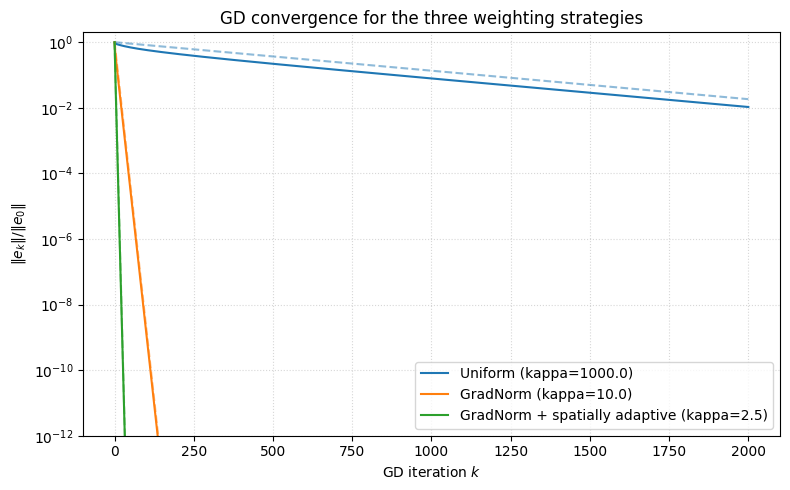

In [6]:
n_iters = 2000

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for (name, spec), color in zip(strategies.items(), colors):
    history = simulate_gd(spec, n_iters=n_iters)
    k = cond_number(spec)
    rho = (k - 1.0) / (k + 1.0)
    ax.semilogy(history, color=color, label=f"{name} (kappa={k:.1f})")
    ax.semilogy(rho ** np.arange(n_iters + 1), color=color, ls="--", alpha=0.5)

ax.set_xlabel("GD iteration $k$")
ax.set_ylabel(r"$\|e_k\|/\|e_0\|$")
ax.set_title("GD convergence for the three weighting strategies")
ax.set_ylim(1e-12, 2)
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Spectrum visualization

It is useful to see directly how each strategy reshapes the composite spectrum.
We plot the eigenvalues on a log scale, with the residual-block eigenvalues marked by circles
and the boundary-block ones by squares.

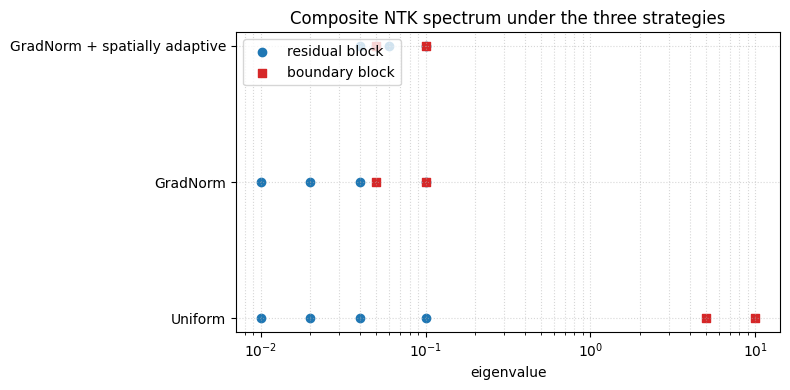

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

rows = []
rows.append(("Uniform", 1.0 * spec_residual, 1.0 * spec_boundary))
rows.append(("GradNorm", 1.0 * spec_residual, (spec_residual.max() / spec_boundary.max()) * spec_boundary))
rows.append(("GradNorm + spatially adaptive", 1.0 * spec_residual_xi, (spec_residual.max() / spec_boundary.max()) * spec_boundary))

for i, (name, sR, sB) in enumerate(rows):
    ax.scatter(sR, [i] * len(sR), marker="o", color="#1f77b4", label="residual block" if i == 0 else None)
    ax.scatter(sB, [i] * len(sB), marker="s", color="#d62728", label="boundary block" if i == 0 else None)

ax.set_xscale("log")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([name for name, _, _ in rows])
ax.set_xlabel("eigenvalue")
ax.set_title("Composite NTK spectrum under the three strategies")
ax.legend(loc="upper left")
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Discussion

The numerical experiment confirms the predictions of the analysis:

- With **uniform weights**, $\kappa(\Theta^{(\gamma)}) = 1000$ is dominated by the gross scale mismatch between the residual and boundary blocks. The contraction factor is $\rho \approx 0.998$, and the boundary block converges almost immediately while the residual block barely moves.
- **GradNorm-style balancing** sets $\gamma_\Gamma = \lambda_{\max}^{(\Omega)} / \lambda_{\max}^{(\Gamma)}$, collapsing $\kappa$ down to $\max(\kappa^{(\Omega)}, \kappa^{(\Gamma)}) = 10$. The eigenvalues across blocks are now comparable, and the convergence accelerates by roughly two orders of magnitude.
- Adding **spatially adaptive (intra-block) weighting** further compresses the residual-block spectrum, bringing $\kappa^{(\Omega)}$ down from $10$ to $\approx 2.5$. The overall condition number reaches $\kappa(\Theta^{(\gamma)}) \approx 2.5$ and only a handful of iterations are needed to reduce the error by a factor of ten.

The two strategies act on disjoint parts of the spectrum: GradNorm fixes the inter-block scale mismatch; spatially adaptive weighting compresses the spectrum within the residual block. Combining them reaches the lowest $\kappa$ achievable from this set of weights, in line with the closed-form prediction $\kappa(\Theta^{(\gamma)}) \approx \max(\kappa^{(\Omega)}_\xi, \kappa^{(\Gamma)})$.